In [ ]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [ ]:
import os
print("Current working directory:")
print(os.getcwd())
print("\nFiles available:")
print(os.listdir())

Current working directory:
/content

Files available:
['.config', 'coupon_redempt.csv', 'coupon.csv', 'transaction_data.csv', 'causal_data.csv', 'product.csv', 'campaign_desc.csv', 'hh_demographic.csv', 'campaign_table.csv', 'sample_data']


In [ ]:
# Load Dunnhumby datasets
transaction_df = pd.read_csv("transaction_data.csv")
product_df = pd.read_csv("product.csv")
household_df = pd.read_csv("hh_demographic.csv")
campaign_desc_df = pd.read_csv("campaign_desc.csv")
campaign_table_df = pd.read_csv("campaign_table.csv")
coupon_df = pd.read_csv("coupon.csv")
coupon_redempt_df = pd.read_csv("coupon_redempt.csv")

In [ ]:
os.listdir()

['.config',
 'coupon_redempt.csv',
 'coupon.csv',
 'transaction_data.csv',
 'causal_data.csv',
 'product.csv',
 'campaign_desc.csv',
 'hh_demographic.csv',
 'campaign_table.csv',
 'sample_data']

In [ ]:
datasets = {
    "Transaction": transaction_df,
    "Product": product_df,
    "Household Demographic": household_df,
    "Campaign Description": campaign_desc_df,
    "Campaign Table": campaign_table_df,
    "Coupon": coupon_df,
    "Coupon Redemption": coupon_redempt_df
}
for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Transaction: 2,595,732 rows × 12 columns
Product: 92,353 rows × 7 columns
Household Demographic: 801 rows × 8 columns
Campaign Description: 30 rows × 4 columns
Campaign Table: 7,208 rows × 3 columns
Coupon: 124,548 rows × 3 columns
Coupon Redemption: 2,318 rows × 4 columns


In [ ]:
dataset_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
    "Missing Values": [df.isna().sum().sum() for df in datasets.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})
dataset_summary

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Transaction,2595732,12,0,0
1,Product,92353,7,0,0
2,Household Demographic,801,8,0,0
3,Campaign Description,30,4,0,0
4,Campaign Table,7208,3,0,0
5,Coupon,124548,3,0,5164
6,Coupon Redemption,2318,4,0,0


In [ ]:
transaction_df.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.390,364,-0.600,1631,1,0.000,0.000
1,2375,26984851472,1,1033142,1,0.820,364,0.000,1631,1,0.000,0.000
2,2375,26984851472,1,1036325,1,0.990,364,-0.300,1631,1,0.000,0.000
3,2375,26984851472,1,1082185,1,1.210,364,0.000,1631,1,0.000,0.000
4,2375,26984851472,1,8160430,1,1.500,364,-0.390,1631,1,0.000,0.000


In [ ]:
transaction_df.tail()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
2595727,1598,42305362535,711,92130,1,0.990,3228,0.000,1520,102,0.000,0.000
2595728,1598,42305362535,711,114102,1,8.890,3228,0.000,1520,102,0.000,0.000
2595729,1598,42305362535,711,133449,1,6.990,3228,0.000,1520,102,0.000,0.000
2595730,1598,42305362535,711,6923644,1,4.500,3228,-0.490,1520,102,0.000,0.000
2595731,1598,42305362535,711,14055192,1,6.990,3228,0.000,1520,102,0.000,0.000


In [ ]:
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2595732 entries, 0 to 2595731
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   TRANS_TIME         int64  
 9   WEEK_NO            int64  
 10  COUPON_DISC        float64
 11  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(8)
memory usage: 237.6 MB


In [ ]:
transaction_df.describe().T

,count,mean,std,min,25%,50%,75%,max
household_key,"2,595,732.000","1,271.953",726.066,1.000,656.000,"1,272.000","1,913.000","2,500.000"
BASKET_ID,"2,595,732.000","34,026,199,138.887","4,711,649,037.862","26,984,851,472.000","30,408,046,256.000","32,760,806,548.000","40,126,853,628.000","42,305,362,535.000"
DAY,"2,595,732.000",388.756,189.721,1.000,229.000,390.000,553.000,711.000
PRODUCT_ID,"2,595,732.000","2,891,435.160","3,837,403.689","25,671.000","917,459.000","1,028,816.000","1,133,018.000","18,316,298.000"
QUANTITY,"2,595,732.000",100.429,"1,153.436",0.000,1.000,1.000,1.000,"89,638.000"
SALES_VALUE,"2,595,732.000",3.104,4.182,0.000,1.290,2.000,3.490,840.000
STORE_ID,"2,595,732.000","3,142.673","8,937.113",1.000,330.000,372.000,422.000,"34,280.000"
RETAIL_DISC,"2,595,732.000",-0.539,1.249,-180.000,-0.690,-0.010,0.000,3.990
TRANS_TIME,"2,595,732.000","1,561.586",399.838,0.000,"1,308.000","1,613.000","1,843.000","2,359.000"
WEEK_NO,"2,595,732.000",56.221,27.102,1.000,33.000,56.000,80.000,102.000


In [ ]:
transaction_df.nunique().sort_values(ascending=False)

,0
BASKET_ID,276484
PRODUCT_ID,92339
QUANTITY,11746
SALES_VALUE,5502
household_key,2500
RETAIL_DISC,2414
TRANS_TIME,1440
DAY,711
STORE_ID,582
COUPON_DISC,415


In [ ]:
transaction_df.nunique().sort_values(ascending=False)

,0
BASKET_ID,276484
PRODUCT_ID,92339
QUANTITY,11746
SALES_VALUE,5502
household_key,2500
RETAIL_DISC,2414
TRANS_TIME,1440
DAY,711
STORE_ID,582
COUPON_DISC,415


In [ ]:
transaction_statistics = {
    "Total Transactions": len(transaction_df),
    "Unique Households": transaction_df["household_key"].nunique(),
    "Unique Baskets": transaction_df["BASKET_ID"].nunique(),
    "Unique Products": transaction_df["PRODUCT_ID"].nunique(),
    "Unique Stores": transaction_df["STORE_ID"].nunique(),
    "Number of Days": transaction_df["DAY"].nunique(),
    "Number of Weeks": transaction_df["WEEK_NO"].nunique()
}
transaction_statistics

{'Total Transactions': 2595732,
 'Unique Households': 2500,
 'Unique Baskets': 276484,
 'Unique Products': 92339,
 'Unique Stores': 582,
 'Number of Days': 711,
 'Number of Weeks': 102}

In [ ]:
sales_statistics = transaction_df["SALES_VALUE"].describe()
sales_statistics

,SALES_VALUE
count,"2,595,732.000"
mean,3.104
std,4.182
min,0.000
25%,1.290
50%,2.000
75%,3.490
max,840.000


In [ ]:
sales_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation",
        "25th Percentile",
        "75th Percentile"
    ],
    "SALES_VALUE": [
        transaction_df["SALES_VALUE"].min(),
        transaction_df["SALES_VALUE"].max(),
        transaction_df["SALES_VALUE"].mean(),
        transaction_df["SALES_VALUE"].median(),
        transaction_df["SALES_VALUE"].std(),
        transaction_df["SALES_VALUE"].quantile(0.25),
        transaction_df["SALES_VALUE"].quantile(0.75)
    ]
})
sales_summary

,Statistic,SALES_VALUE
0,Minimum,0.000
1,Maximum,840.000
2,Mean,3.104
3,Median,2.000
4,Standard Deviation,4.182
5,25th Percentile,1.290
6,75th Percentile,3.490


In [ ]:
important_variables = [
    "QUANTITY",
    "SALES_VALUE",
    "RETAIL_DISC",
    "COUPON_DISC",
    "COUPON_MATCH_DISC"
]
descriptive_statistics = transaction_df[important_variables].describe().T
descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
QUANTITY,"2,595,732.000",100.429,"1,153.436",0.000,1.000,1.000,1.000,"89,638.000"
SALES_VALUE,"2,595,732.000",3.104,4.182,0.000,1.290,2.000,3.490,840.000
RETAIL_DISC,"2,595,732.000",-0.539,1.249,-180.000,-0.690,-0.010,0.000,3.990
COUPON_DISC,"2,595,732.000",-0.016,0.217,-55.930,0.000,0.000,0.000,0.000
COUPON_MATCH_DISC,"2,595,732.000",-0.003,0.040,-7.700,0.000,0.000,0.000,0.000


In [ ]:
missing_values = transaction_df.isnull().sum()
missing_values[missing_values > 0]

,0


In [ ]:
duplicate_count = transaction_df.duplicated().sum()
print(f"Duplicate transaction records: {duplicate_count:,}")

Duplicate transaction records: 0


In [ ]:
product_df.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [ ]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   PRODUCT_ID            92353 non-null  int64 
 1   MANUFACTURER          92353 non-null  int64 
 2   DEPARTMENT            92353 non-null  object
 3   BRAND                 92353 non-null  object
 4   COMMODITY_DESC        92353 non-null  object
 5   SUB_COMMODITY_DESC    92353 non-null  object
 6   CURR_SIZE_OF_PRODUCT  92353 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.9+ MB


In [ ]:
product_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PRODUCT_ID,"92,353.000",NaN,NaN,NaN,"5,328,352.837","5,359,937.078","25,671.000","970,628.000","1,621,091.000","9,704,770.000","18,316,298.000"
MANUFACTURER,"92,353.000",NaN,NaN,NaN,"1,739.228","1,818.270",1.000,328.000,"1,094.000","2,264.000","6,477.000"
DEPARTMENT,92353,44,GROCERY,39021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BRAND,92353,2,National,78537,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COMMODITY_DESC,92353,308,GREETING CARDS/WRAP/PARTY SPLY,2785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SUB_COMMODITY_DESC,92353,2383,CARDS EVERYDAY,1005,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CURR_SIZE_OF_PRODUCT,92353,4345,,30607,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
product_df.nunique().sort_values(ascending=False)

,0
PRODUCT_ID,92353
MANUFACTURER,6476
CURR_SIZE_OF_PRODUCT,4345
SUB_COMMODITY_DESC,2383
COMMODITY_DESC,308
DEPARTMENT,44
BRAND,2


In [ ]:
product_df.nunique().sort_values(ascending=False)

,0
PRODUCT_ID,92353
MANUFACTURER,6476
CURR_SIZE_OF_PRODUCT,4345
SUB_COMMODITY_DESC,2383
COMMODITY_DESC,308
DEPARTMENT,44
BRAND,2


In [ ]:
print("Product columns:")
for column in product_df.columns:
    print("-", column)

Product columns:
- PRODUCT_ID
- MANUFACTURER
- DEPARTMENT
- BRAND
- COMMODITY_DESC
- SUB_COMMODITY_DESC
- CURR_SIZE_OF_PRODUCT


In [ ]:
household_df.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [ ]:
household_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   AGE_DESC             801 non-null    object
 1   MARITAL_STATUS_CODE  801 non-null    object
 2   INCOME_DESC          801 non-null    object
 3   HOMEOWNER_DESC       801 non-null    object
 4   HH_COMP_DESC         801 non-null    object
 5   HOUSEHOLD_SIZE_DESC  801 non-null    object
 6   KID_CATEGORY_DESC    801 non-null    object
 7   household_key        801 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 50.2+ KB


In [ ]:
household_df.nunique().sort_values(ascending=False)

,0
household_key,801
INCOME_DESC,12
HH_COMP_DESC,6
AGE_DESC,6
HOUSEHOLD_SIZE_DESC,5
HOMEOWNER_DESC,5
KID_CATEGORY_DESC,4
MARITAL_STATUS_CODE,3


In [ ]:
household_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
AGE_DESC,801,6,45-54,288,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MARITAL_STATUS_CODE,801,3,U,344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCOME_DESC,801,12,50-74K,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HOMEOWNER_DESC,801,5,Homeowner,504,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HH_COMP_DESC,801,6,2 Adults No Kids,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HOUSEHOLD_SIZE_DESC,801,5,2,318,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KID_CATEGORY_DESC,801,4,None/Unknown,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_key,801.000,NaN,NaN,NaN,"1,235.176",736.805,1.000,596.000,"1,218.000","1,914.000","2,499.000"


In [ ]:
campaign_desc_df.head()

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684


In [ ]:
campaign_desc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   DESCRIPTION  30 non-null     object
 1   CAMPAIGN     30 non-null     int64 
 2   START_DAY    30 non-null     int64 
 3   END_DAY      30 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.1+ KB


In [ ]:
campaign_desc_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DESCRIPTION,30,3,TypeB,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAMPAIGN,30.000,NaN,NaN,NaN,15.500,8.803,1.000,8.250,15.500,22.750,30.000
START_DAY,30.000,NaN,NaN,NaN,463.867,134.488,224.000,360.000,470.000,584.000,659.000
END_DAY,30.000,NaN,NaN,NaN,510.467,137.731,264.000,405.750,502.000,640.250,719.000


In [ ]:
campaign_desc_df.nunique()

,0
DESCRIPTION,3
CAMPAIGN,30
START_DAY,27
END_DAY,28


In [ ]:
campaign_table_df.head()

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26
2,TypeA,212,26
3,TypeA,208,26
4,TypeA,192,26


In [ ]:
campaign_table_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7208 entries, 0 to 7207
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   DESCRIPTION    7208 non-null   object
 1   household_key  7208 non-null   int64 
 2   CAMPAIGN       7208 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 169.1+ KB


In [ ]:
campaign_table_df.nunique()

,0
DESCRIPTION,3
household_key,1584
CAMPAIGN,30


In [ ]:
coupon_df.head()

,COUPON_UPC,PRODUCT_ID,CAMPAIGN
0,10000089061,27160,4
1,10000089064,27754,9
2,10000089073,28897,12
3,51800009050,28919,28
4,52100000076,28929,25


In [ ]:
coupon_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124548 entries, 0 to 124547
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   COUPON_UPC  124548 non-null  int64
 1   PRODUCT_ID  124548 non-null  int64
 2   CAMPAIGN    124548 non-null  int64
dtypes: int64(3)
memory usage: 2.9 MB


In [ ]:
coupon_df.nunique()

,0
COUPON_UPC,1135
PRODUCT_ID,44133
CAMPAIGN,30


In [ ]:
coupon_redempt_df.head()

,household_key,DAY,COUPON_UPC,CAMPAIGN
0,1,421,10000085364,8
1,1,421,51700010076,8
2,1,427,54200000033,8
3,1,597,10000085476,18
4,1,597,54200029176,18


In [ ]:
coupon_redempt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   household_key  2318 non-null   int64
 1   DAY            2318 non-null   int64
 2   COUPON_UPC     2318 non-null   int64
 3   CAMPAIGN       2318 non-null   int64
dtypes: int64(4)
memory usage: 72.6 KB


In [ ]:
coupon_redempt_df.nunique()

,0
household_key,434
DAY,328
COUPON_UPC,556
CAMPAIGN,30


In [ ]:
print("Transaction PRODUCT_ID sample:")
print(transaction_df["PRODUCT_ID"].head())
print("\nProduct PRODUCT_ID sample:")
print(product_df["PRODUCT_ID"].head())

Transaction PRODUCT_ID sample:
0    1004906
1    1033142
2    1036325
3    1082185
4    8160430
Name: PRODUCT_ID, dtype: int64

Product PRODUCT_ID sample:
0    25671
1    26081
2    26093
3    26190
4    26355
Name: PRODUCT_ID, dtype: int64


In [ ]:
print("Transaction household keys:")
print(transaction_df["household_key"].nunique())
print("Household demographic keys:")
print(household_df["household_key"].nunique())

Transaction household keys:
2500
Household demographic keys:
801


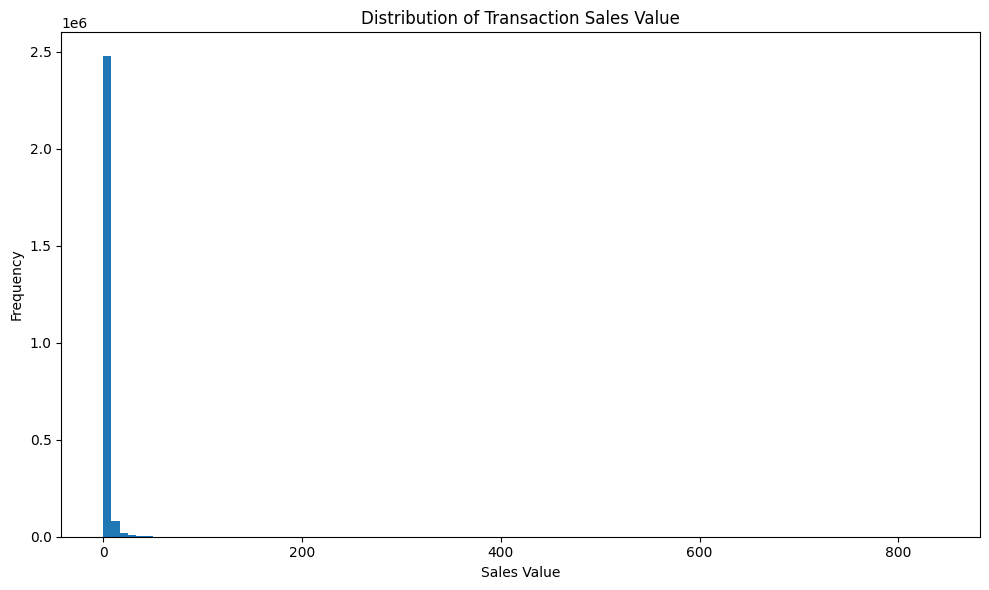

In [ ]:
# Sales distribution
plt.figure(figsize=(10, 6))
plt.hist(
    transaction_df["SALES_VALUE"],
    bins=100
)
plt.xlabel("Sales Value")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Sales Value")
plt.tight_layout()
plt.show()

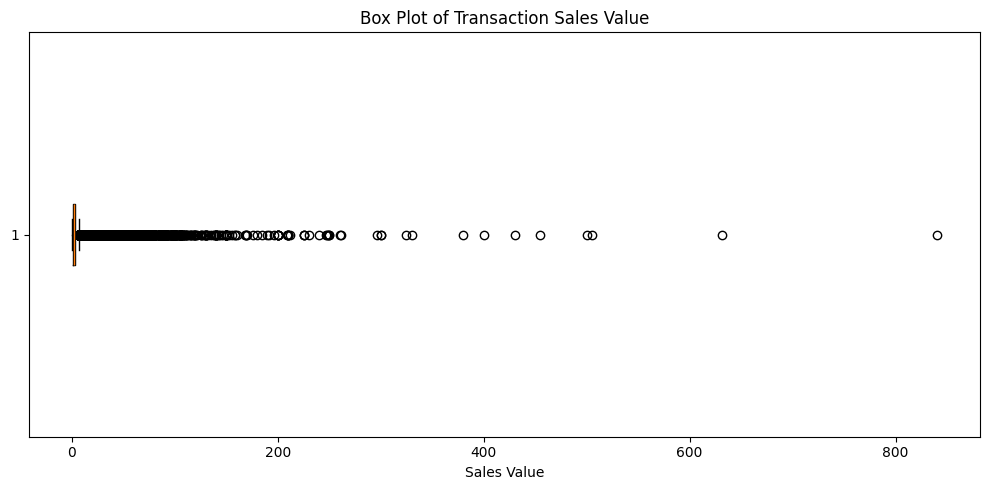

In [ ]:
# Sales boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(transaction_df["SALES_VALUE"], vert=False)
plt.xlabel("Sales Value")
plt.title("Box Plot of Transaction Sales Value")
plt.tight_layout()
plt.show()

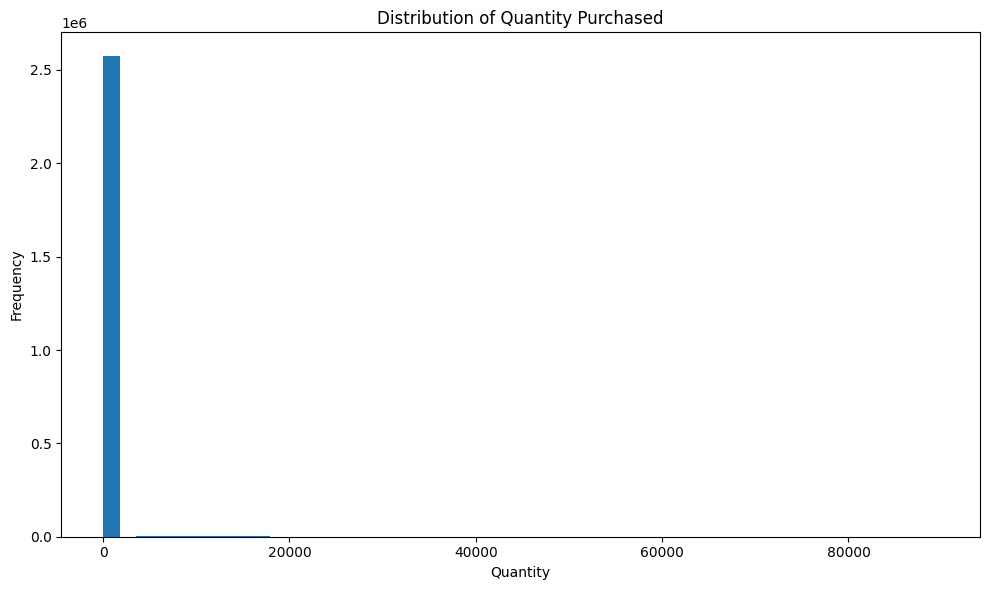

In [ ]:
# Quantity distribution
plt.figure(figsize=(10, 6))
plt.hist(
    transaction_df["QUANTITY"],
    bins=50
)
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.title("Distribution of Quantity Purchased")
plt.tight_layout()
plt.show()

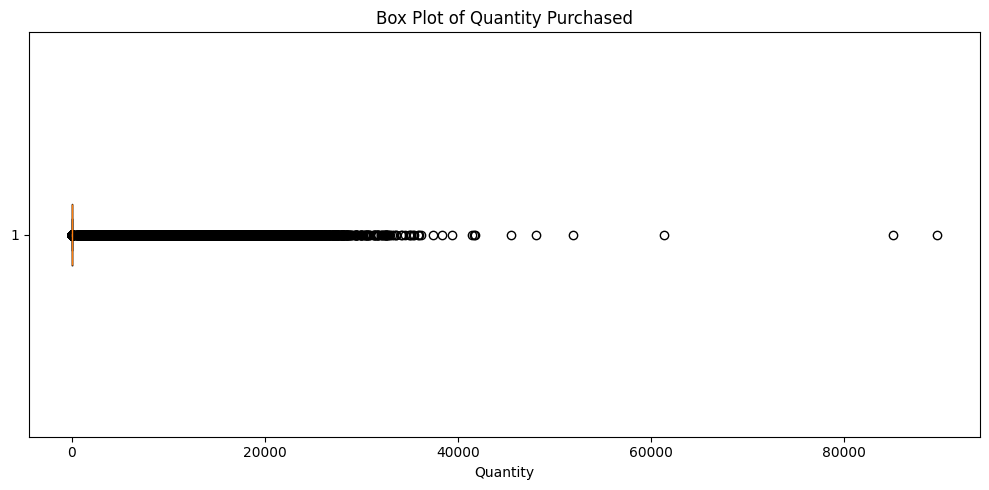

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(transaction_df["QUANTITY"], vert=False)
plt.xlabel("Quantity")
plt.title("Box Plot of Quantity Purchased")
plt.tight_layout()
plt.show()

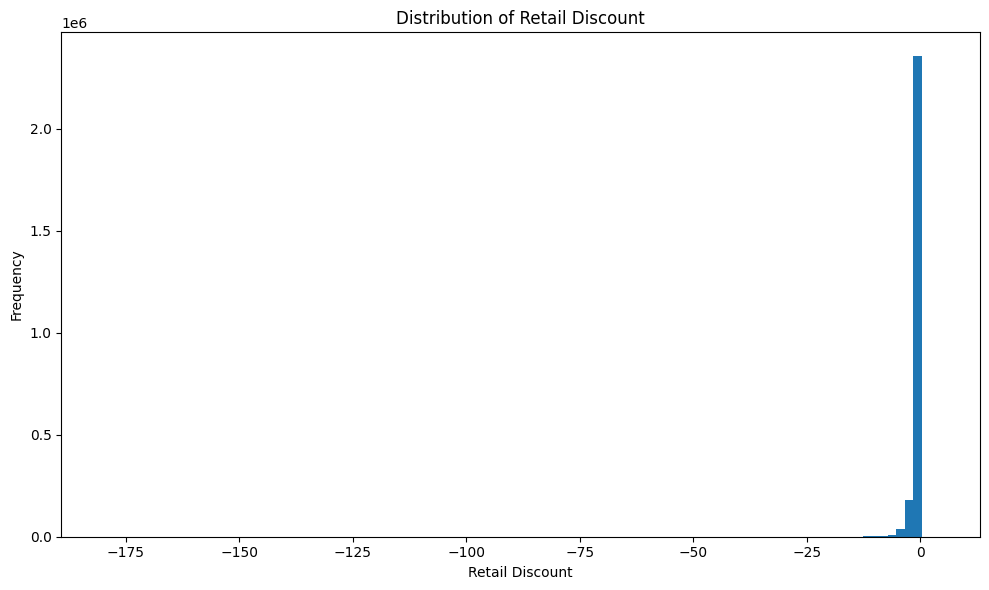

In [ ]:
# Discount distributions
plt.figure(figsize=(10, 6))
plt.hist(
    transaction_df["RETAIL_DISC"],
    bins=100
)
plt.xlabel("Retail Discount")
plt.ylabel("Frequency")
plt.title("Distribution of Retail Discount")
plt.tight_layout()
plt.show()

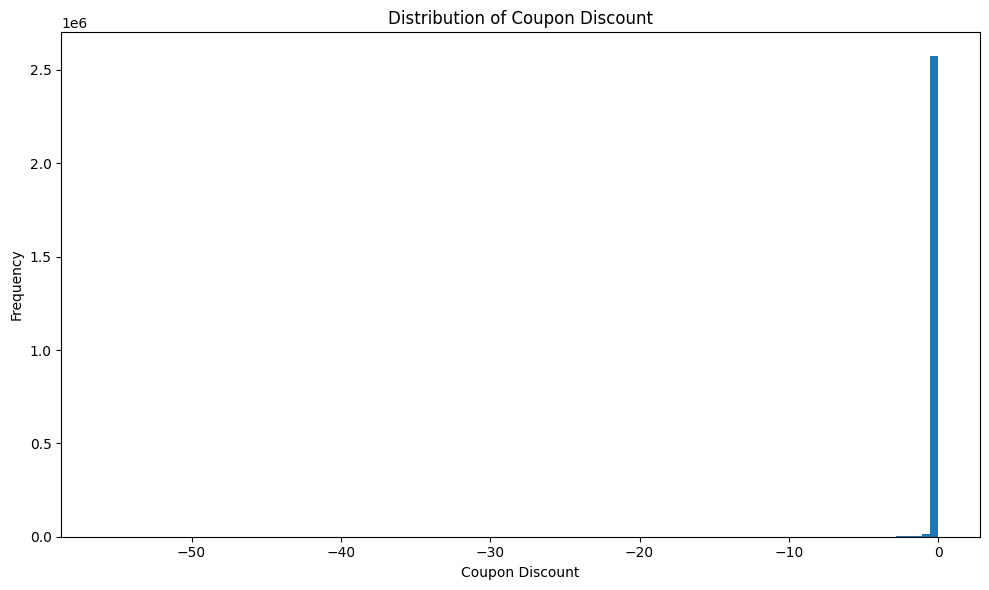

In [ ]:
# Coupon discount
plt.figure(figsize=(10, 6))
plt.hist(
    transaction_df["COUPON_DISC"],
    bins=100
)
plt.xlabel("Coupon Discount")
plt.ylabel("Frequency")
plt.title("Distribution of Coupon Discount")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation with SALES_VALUE
numeric_columns = [
    "household_key",
    "BASKET_ID",
    "DAY",
    "PRODUCT_ID",
    "QUANTITY",
    "SALES_VALUE",
    "STORE_ID",
    "RETAIL_DISC",
    "TRANS_TIME",
    "WEEK_NO",
    "COUPON_DISC",
    "COUPON_MATCH_DISC"
]

correlation_with_sales = (
    transaction_df[numeric_columns]
    .corr()["SALES_VALUE"]
    .sort_values(ascending=False)
)
correlation_with_sales

,SALES_VALUE
SALES_VALUE,1.000
QUANTITY,0.588
PRODUCT_ID,0.127
DAY,0.013
WEEK_NO,0.013
BASKET_ID,0.012
household_key,0.005
COUPON_MATCH_DISC,0.004
STORE_ID,-0.001
TRANS_TIME,-0.017


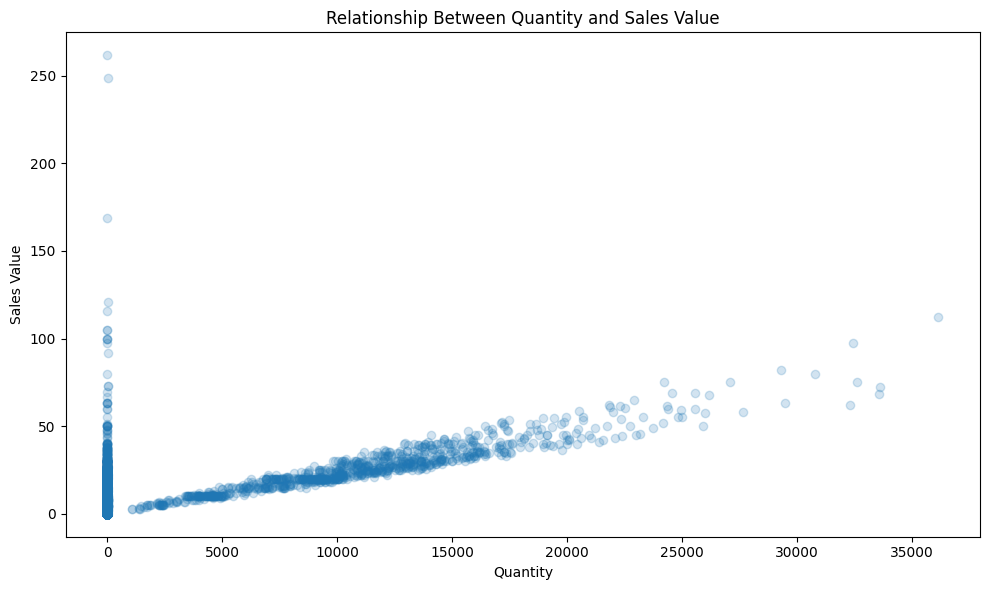

In [ ]:
# Sales vs Quantity
sample_df = transaction_df.sample(
    n=min(100000, len(transaction_df)),
    random_state=42
)
plt.figure(figsize=(10, 6))

plt.scatter(
    sample_df["QUANTITY"],
    sample_df["SALES_VALUE"],
    alpha=0.2
)
plt.xlabel("Quantity")
plt.ylabel("Sales Value")
plt.title("Relationship Between Quantity and Sales Value")
plt.tight_layout()
plt.show()

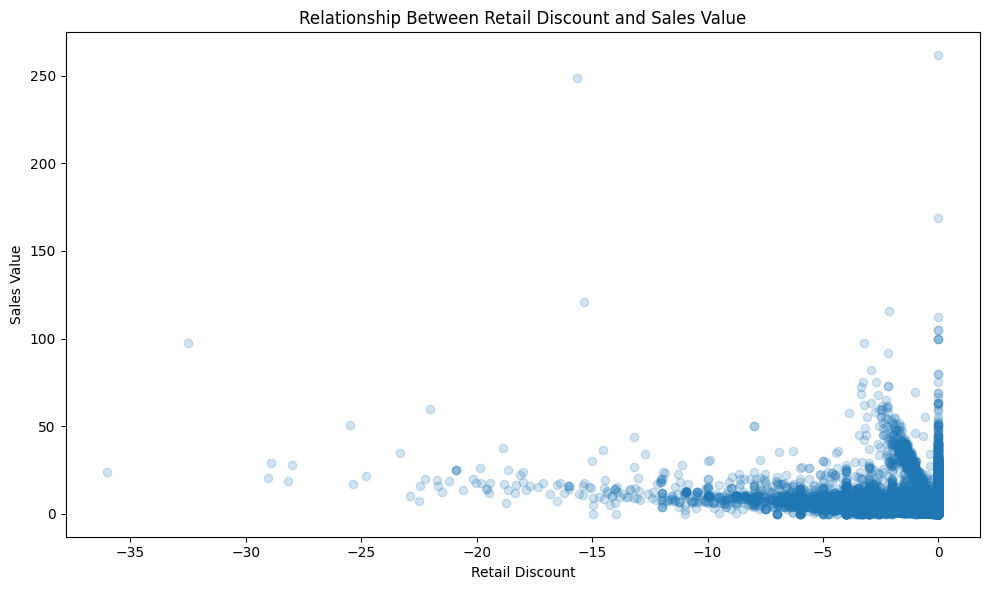

In [ ]:
# Sales vs Retail Discount
plt.figure(figsize=(10, 6))
plt.scatter(
    sample_df["RETAIL_DISC"],
    sample_df["SALES_VALUE"],
    alpha=0.2
)
plt.xlabel("Retail Discount")
plt.ylabel("Sales Value")
plt.title("Relationship Between Retail Discount and Sales Value")
plt.tight_layout()
plt.show()

In [ ]:
daily_sales = (
    transaction_df
    .groupby("DAY", as_index=False)["SALES_VALUE"]
    .sum()
    .rename(columns={"SALES_VALUE": "DAILY_SALES"})
)
daily_sales.head()

,DAY,DAILY_SALES
0,1,549.310
1,2,458.910
2,3,"1,560.370"
3,4,"1,785.640"
4,5,856.930


In [ ]:
daily_sales.shape

(711, 2)

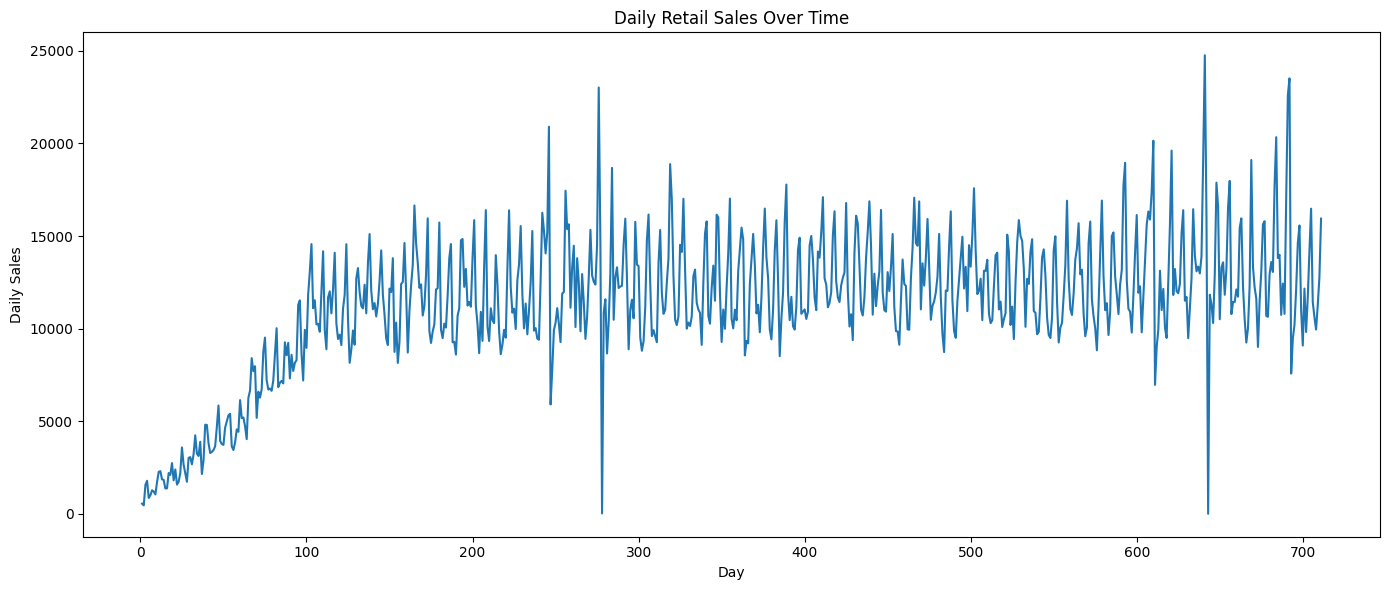

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(
    daily_sales["DAY"],
    daily_sales["DAILY_SALES"]
)
plt.xlabel("Day")
plt.ylabel("Daily Sales")
plt.title("Daily Retail Sales Over Time")
plt.tight_layout()
plt.show()

In [ ]:
weekly_sales = (
    transaction_df
    .groupby("WEEK_NO", as_index=False)["SALES_VALUE"]
    .sum()
    .rename(columns={"SALES_VALUE": "WEEKLY_SALES"})
)
weekly_sales.head()

,WEEK_NO,WEEKLY_SALES
0,1,"5,211.160"
1,2,"10,821.350"
2,3,"13,498.200"
3,4,"15,965.990"
4,5,"20,139.820"


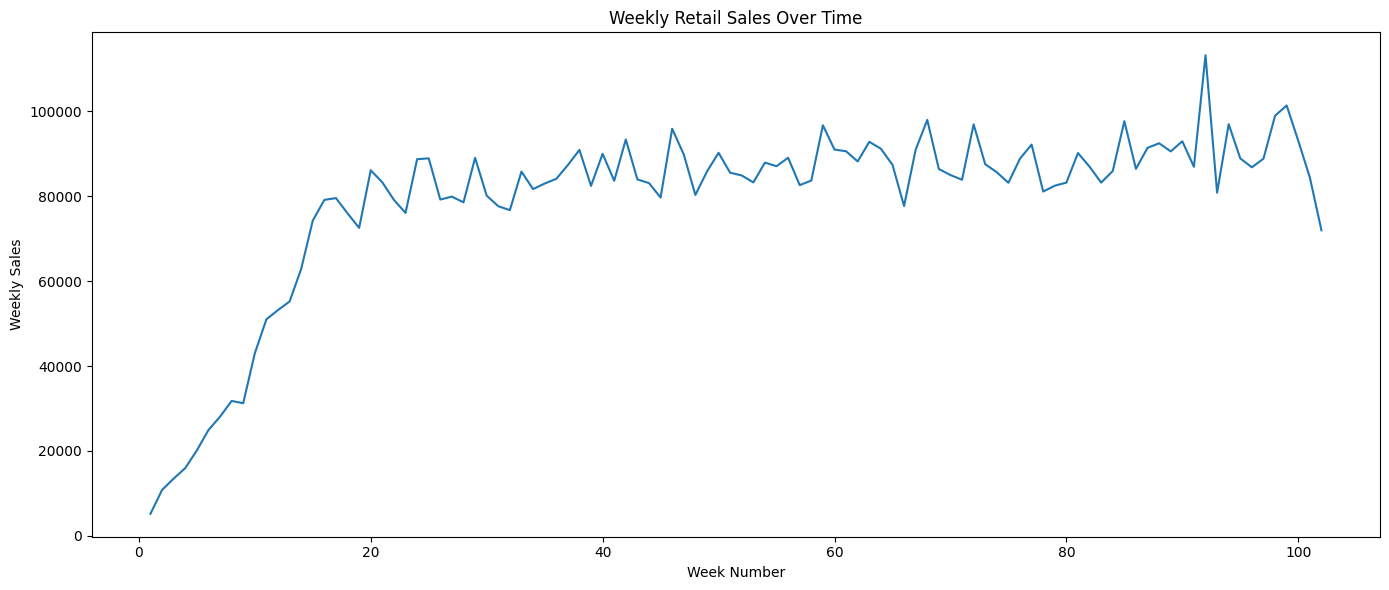

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_sales["WEEK_NO"],
    weekly_sales["WEEKLY_SALES"]
)

plt.xlabel("Week Number")
plt.ylabel("Weekly Sales")
plt.title("Weekly Retail Sales Over Time")

plt.tight_layout()
plt.show()

In [ ]:
zero_sales_days = daily_sales[daily_sales["DAILY_SALES"] == 0]
zero_sales_days

,DAY,DAILY_SALES


In [ ]:
print("Number of zero-sales days:", len(zero_sales_days))
print("Zero-sales days:")
print(zero_sales_days["DAY"].tolist())

Number of zero-sales days: 0
Zero-sales days:
[]


In [ ]:
transaction_df[
    transaction_df["DAY"].isin(zero_sales_days["DAY"])
].groupby("DAY").agg(
    transactions=("BASKET_ID", "count"),
    total_quantity=("QUANTITY", "sum"),
    total_sales=("SALES_VALUE", "sum")
)

,transactions,total_quantity,total_sales
DAY,,,


In [ ]:
for col in ["QUANTITY", "SALES_VALUE", "RETAIL_DISC",
            "COUPON_DISC", "COUPON_MATCH_DISC"]:

    print(f"\n{col}")
    print("Negative:", (transaction_df[col] < 0).sum())
    print("Zero:", (transaction_df[col] == 0).sum())


QUANTITY
Negative: 0
Zero: 14466

SALES_VALUE
Negative: 0
Zero: 18850

RETAIL_DISC
Negative: 1303026
Zero: 1292670

COUPON_DISC
Negative: 36422
Zero: 2559310

COUPON_MATCH_DISC
Negative: 17449
Zero: 2578283


In [ ]:
transaction_df[
    transaction_df["SALES_VALUE"] < 0
].head(20)

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC


In [ ]:
store_analysis = (
    transaction_df
    .groupby("STORE_ID")
    .agg(
        transactions=("BASKET_ID", "count"),
        unique_baskets=("BASKET_ID", "nunique"),
        unique_households=("household_key", "nunique"),
        unique_products=("PRODUCT_ID", "nunique"),
        total_sales=("SALES_VALUE", "sum"),
        average_sales=("SALES_VALUE", "mean"),
        total_quantity=("QUANTITY", "sum")
    )
    .reset_index()
)

store_analysis.head()

,STORE_ID,transactions,unique_baskets,unique_households,unique_products,total_sales,average_sales,total_quantity
0,1,4,3,2,3,29.890,7.473,9689
1,2,5,3,1,5,22.060,4.412,5
2,12,4,1,1,4,12.060,3.015,5
3,19,8,3,1,8,28.490,3.561,4864
4,20,2,2,1,2,20.000,10.000,4590


In [ ]:
store_analysis.sort_values(
    "total_sales",
    ascending=False
).head(20)

In [ ]:
store_analysis.describe().T

,count,mean,std,min,25%,50%,75%,max
STORE_ID,582.000,"3,314.560","7,160.747",1.000,416.250,"1,083.500","3,067.250","34,280.000"
transactions,582.000,"4,460.021","10,273.967",1.000,7.000,30.000,285.500,"75,573.000"
unique_baskets,582.000,475.058,"1,091.262",1.000,1.000,4.000,41.000,"7,724.000"
unique_households,582.000,23.474,48.788,1.000,1.000,2.000,6.000,278.000
unique_products,582.000,"1,615.242","3,426.655",1.000,7.000,27.500,223.250,"19,002.000"
total_sales,582.000,"13,844.438","32,845.126",0.000,27.973,100.930,992.642,"267,614.340"
average_sales,582.000,4.758,6.470,0.000,2.503,3.031,4.085,72.000
total_quantity,582.000,"447,913.440","1,897,852.115",1.000,14.000,104.000,"22,073.750","16,860,489.000"


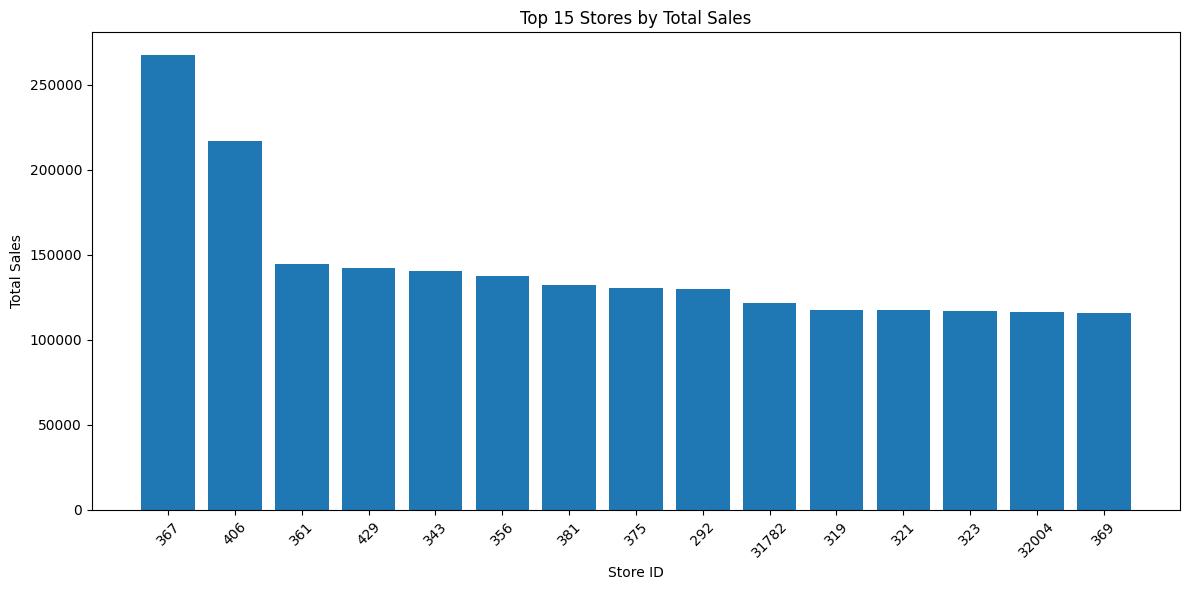

In [ ]:
# Store sales
top_stores = (
    store_analysis
    .sort_values("total_sales", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_stores["STORE_ID"].astype(str),
    top_stores["total_sales"]
)

plt.xlabel("Store ID")
plt.ylabel("Total Sales")
plt.title("Top 15 Stores by Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
store_analysis_clean = (
    transaction_df
    .groupby("STORE_ID")
    .agg(
        transactions=("BASKET_ID", "count"),
        unique_baskets=("BASKET_ID", "nunique"),
        unique_households=("household_key", "nunique"),
        unique_products=("PRODUCT_ID", "nunique"),
        total_sales=("SALES_VALUE", "sum"),
        average_transaction_sales=("SALES_VALUE", "mean"),
        total_quantity=("QUANTITY", "sum")
    )
    .reset_index()
)

store_analysis_clean.head(20)

,STORE_ID,transactions,unique_baskets,unique_households,unique_products,total_sales,average_transaction_sales,total_quantity
0,1,4,3,2,3,29.890,7.473,9689
1,2,5,3,1,5,22.060,4.412,5
2,12,4,1,1,4,12.060,3.015,5
3,19,8,3,1,8,28.490,3.561,4864
4,20,2,2,1,2,20.000,10.000,4590
5,21,4,2,1,4,7.350,1.837,4
6,22,4,1,1,4,24.770,6.192,4
7,26,2,1,1,2,1.750,0.875,2
8,27,836,67,22,695,"2,846.640",3.405,1051
9,37,3,1,1,3,7.270,2.423,3


In [74]:
print("Top 10 stores by total sales")
display(
    store_analysis_clean
    .sort_values("total_sales", ascending=False)
    .head(10)
)
print("\nBottom 10 stores by total sales")
display(
    store_analysis_clean
    .sort_values("total_sales", ascending=True)
    .head(10)
)

Top 10 stores by total sales


,STORE_ID,transactions,unique_baskets,unique_households,unique_products,total_sales,average_transaction_sales,total_quantity
118,367,75573,7724,264,19002,"267,614.340",3.541,12743472
139,406,59331,5422,134,15280,"216,781.770",3.654,16044214
112,361,41101,5146,98,11891,"144,698.850",3.521,9012499
151,429,30802,3883,99,10601,"142,391.010",4.623,16860489
102,343,41348,5141,237,12913,"140,455.750",3.397,9582406
108,356,49332,4266,111,14036,"137,588.680",2.789,64388
127,381,45268,5047,278,12928,"132,488.150",2.927,62238
124,375,31437,4110,217,11257,"130,396.510",4.148,14993687
67,292,45240,3975,194,12669,"130,005.180",2.874,61243
560,31782,40949,4496,137,12213,"121,726.540",2.973,53296



Bottom 10 stores by total sales


,STORE_ID,transactions,unique_baskets,unique_households,unique_products,total_sales,average_transaction_sales,total_quantity
301,1235,1,1,1,1,0.000,0.000,1
211,610,1,1,1,1,0.500,0.500,1
59,256,1,1,1,1,0.760,0.760,1
223,639,2,1,1,2,0.850,0.425,2
265,765,1,1,1,1,1.000,1.000,6
330,2760,1,1,1,1,1.000,1.000,2
190,551,1,1,1,1,1.000,1.000,2
473,3209,1,1,1,1,1.190,1.190,1
306,1433,1,1,1,1,1.290,1.290,1
552,30719,2,1,1,2,1.490,0.745,2


In [75]:
zero_sales_transactions = transaction_df[
    transaction_df["SALES_VALUE"] == 0
]

print("Zero-sales transaction rows:", len(zero_sales_transactions))

display(
    zero_sales_transactions[
        [
            "household_key",
            "BASKET_ID",
            "DAY",
            "PRODUCT_ID",
            "QUANTITY",
            "SALES_VALUE",
            "RETAIL_DISC",
            "COUPON_DISC",
            "COUPON_MATCH_DISC"
        ]
    ].head(20)
)

Zero-sales transaction rows: 18850


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC
97,744,26985165432,1,5978648,0,0.000,0.000,0.000,0.000
128,1287,26985336468,1,5978648,0,0.000,0.000,0.000,0.000
249,2305,26996870743,2,5978656,0,0.000,0.000,-1.000,0.000
293,271,26997082949,2,5978656,0,0.000,0.000,-2.000,0.000
694,315,27008952267,3,957951,0,0.000,0.000,0.000,0.000
766,2110,27009082349,3,837963,1,0.000,0.000,0.000,0.000
996,568,27021090189,4,951412,1,0.000,-1.480,0.000,0.000
1089,14,27021203242,4,6463658,0,0.000,0.000,0.000,0.000
1095,2110,27021248054,4,850115,1,0.000,-3.290,0.000,0.000
1113,2110,27021248054,4,976872,1,0.000,-2.490,0.000,0.000


In [76]:
zero_sales_transactions.describe().T

,count,mean,std,min,25%,50%,75%,max
household_key,"18,850.000","1,281.478",735.151,1.000,641.000,"1,299.000","1,926.000","2,500.000"
BASKET_ID,"18,850.000","34,238,000,282.100","4,725,047,330.518","26,985,165,432.000","30,578,502,755.500","33,132,174,223.000","40,198,827,102.500","42,289,918,892.000"
DAY,"18,850.000",398.547,190.164,1.000,235.000,416.000,559.000,711.000
PRODUCT_ID,"18,850.000","4,349,190.024","3,499,229.347","30,937.000","1,010,611.500","5,978,648.000","5,978,656.000","18,057,119.000"
QUANTITY,"18,850.000",0.241,0.443,0.000,0.000,0.000,0.000,9.000
SALES_VALUE,"18,850.000",0.000,0.000,0.000,0.000,0.000,0.000,0.000
STORE_ID,"18,850.000","3,037.190","8,804.200",27.000,329.000,369.000,422.000,"34,280.000"
RETAIL_DISC,"18,850.000",-0.781,1.816,-39.950,0.000,0.000,0.000,0.010
TRANS_TIME,"18,850.000","1,557.427",417.162,0.000,"1,303.000","1,610.000","1,849.000","2,359.000"
WEEK_NO,"18,850.000",57.625,27.162,1.000,34.000,60.000,81.000,102.000


In [77]:
print(
    "Zero-sales rows with positive quantity:",
    (zero_sales_transactions["QUANTITY"] > 0).sum()
)

print(
    "Zero-sales rows with zero quantity:",
    (zero_sales_transactions["QUANTITY"] == 0).sum()
)

Zero-sales rows with positive quantity: 4451
Zero-sales rows with zero quantity: 14399


In [79]:
transaction_product_ids = transaction_df["PRODUCT_ID"].unique()
product_master_ids = product_df["PRODUCT_ID"].unique()

common_products = np.intersect1d(
    transaction_product_ids,
    product_master_ids
)

print("Unique products in transaction data:", len(transaction_product_ids))
print("Products in product master:", len(product_master_ids))
print("Common products:", len(common_products))
print(
    "Transaction products without product master information:",
    len(set(transaction_product_ids) - set(product_master_ids))
)

Unique products in transaction data: 92339
Products in product master: 92353
Common products: 92339
Transaction products without product master information: 0


In [80]:
transaction_product_df = transaction_df.merge(
    product_df,
    on="PRODUCT_ID",
    how="left",
    validate="many_to_one"
)

print("Original transaction rows:", len(transaction_df))
print("Rows after product merge:", len(transaction_product_df))

Original transaction rows: 2595732
Rows after product merge: 2595732


In [81]:
department_sales = (
    transaction_product_df
    .groupby("DEPARTMENT")
    .agg(
        total_sales=("SALES_VALUE", "sum"),
        total_quantity=("QUANTITY", "sum"),
        transactions=("BASKET_ID", "count"),
        unique_products=("PRODUCT_ID", "nunique")
    )
    .sort_values("total_sales", ascending=False)
    .reset_index()
)

department_sales

,DEPARTMENT,total_sales,total_quantity,transactions,unique_products
0,GROCERY,"4,093,814.140",2194762,1646076,39019
1,DRUG GM,"1,055,358.030",353844,277232,31523
2,PRODUCE,"557,452.110",319993,257290,3117
3,MEAT,"548,786.810",119113,88416,2544
4,KIOSK-GAS,"544,222.280",221254887,22059,16
5,MEAT-PCKGD,"412,436.770",148148,111957,2427
6,DELI,"260,866.510",67026,62787,2354
7,PASTRY,"121,739.860",49820,38179,2149
8,MISC SALES TRAN,"119,960.040",36080860,6050,88
9,NUTRITION,"97,669.040",43253,32164,2913


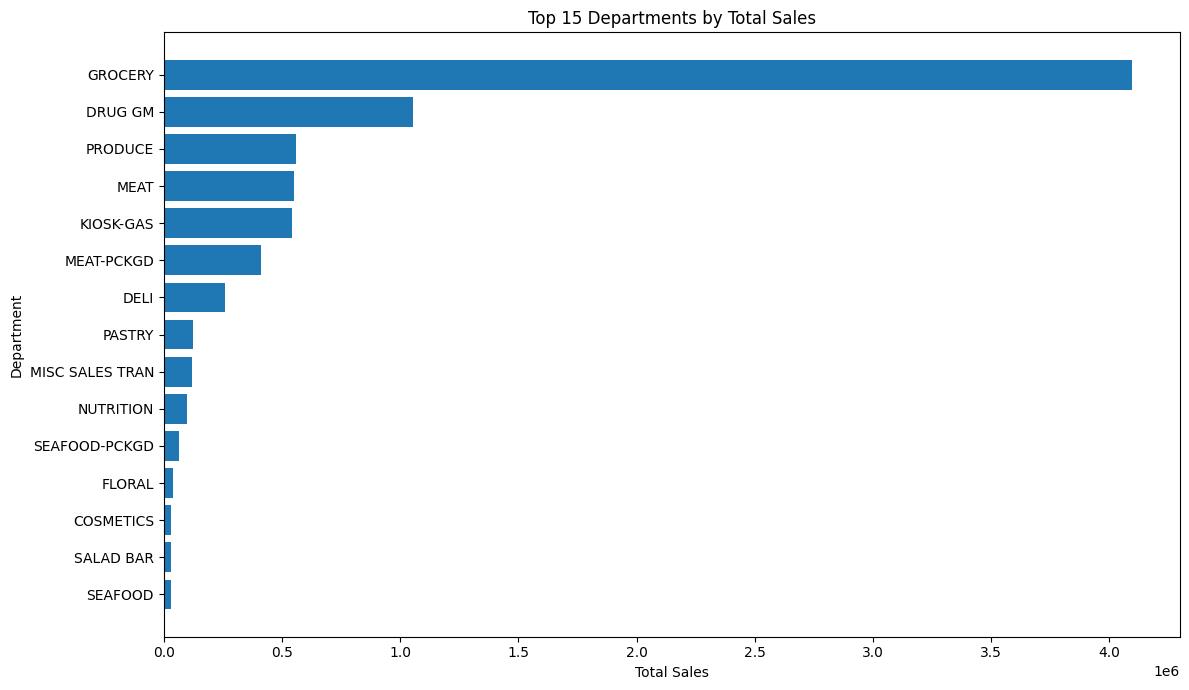

In [82]:
top_departments = department_sales.head(15)
plt.figure(figsize=(12, 7))

plt.barh(
    top_departments["DEPARTMENT"],
    top_departments["total_sales"]
)
plt.xlabel("Total Sales")
plt.ylabel("Department")
plt.title("Top 15 Departments by Total Sales")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [83]:
campaign_desc_df

,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684
5,TypeB,21,624,656
6,TypeB,22,624,656
7,TypeA,18,587,642
8,TypeB,19,603,635
9,TypeB,17,575,607


In [84]:
campaign_days = []

for _, row in campaign_desc_df.iterrows():
    for day in range(row["START_DAY"], row["END_DAY"] + 1):
        campaign_days.append({
            "DAY": day,
            "CAMPAIGN": row["CAMPAIGN"],
            "DESCRIPTION": row["DESCRIPTION"]
        })

campaign_days_df = pd.DataFrame(campaign_days)

campaign_days_df.head()

,DAY,CAMPAIGN,DESCRIPTION
0,659,24,TypeB
1,660,24,TypeB
2,661,24,TypeB
3,662,24,TypeB
4,663,24,TypeB


In [85]:
print("Campaign days:", len(campaign_days_df))
print("Unique campaign days:", campaign_days_df["DAY"].nunique())
print("Campaigns:", campaign_days_df["CAMPAIGN"].nunique())

Campaign days: 1428
Unique campaign days: 496
Campaigns: 30
